In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn



Dataset Loaded Successfully!

   label                                            message
0      0          Hey are we still meeting for lunch today?
1      1  Congratulations! You have won a $500 gift card...
2      0                  Please send me the project files.
3      1  URGENT! Your mobile number has won 100000 cash...
4      0        Can you pick up groceries on your way home?

Model Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



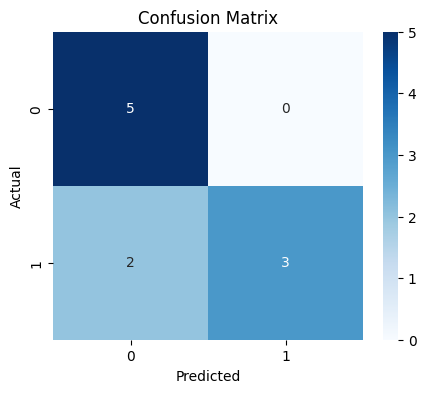


Enter an email message to check (or type 'exit'):  hi can we meet for lunch today?


Prediction: Not Spam Email


In [ ]:
# ================================
# Spam Mail Classifier Notebook
# ================================

# -------------------------------
# 1️⃣ Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------
# 2️⃣ Load Dataset (Safe Parsing)
# -------------------------------
# Make sure spam.csv is in the same folder
df = pd.read_csv("ram.csv", quotechar='"', encoding='utf-8')

# Rename columns (if needed)
df.columns = ['label', 'message']

# Convert labels to numeric
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset Loaded Successfully!\n")
print(df.head())

# -------------------------------
# 3️⃣ Train-Test Split
# -------------------------------
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4️⃣ TF-IDF Vectorization
# -------------------------------
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# -------------------------------
# 5️⃣ Train Logistic Regression Model
# -------------------------------
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# -------------------------------
# 6️⃣ Predict on Test Set
# -------------------------------
y_pred = model.predict(X_test_tfidf)

# -------------------------------
# 7️⃣ Evaluation
# -------------------------------
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# 8️⃣ Test Custom Email Messages
# -------------------------------
while True:
    user_input = input("\nEnter an email message to check (or type 'exit'): ")
    if user_input.lower() == "exit":
        print("Exiting...")
        break
    sample_tfidf = vectorizer.transform([user_input])
    prediction = model.predict(sample_tfidf)
    if prediction[0] == 1:
        print("Prediction: Spam Email")
    else:
        print("Prediction: Not Spam Email")